In [1]:
from datasets import load_dataset

# load data
dataset = load_dataset("Tonic/Health-Bench-Eval-OSS-2025-07", split='oss_eval')


/home/aychen/miniconda3/envs/rubrics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from collections import Counter

# count all long criteria
long_criteria = []
for example in dataset:
    for r in example['rubrics']:
        c = r['criterion']
        if len(c) > 500:
            long_criteria.append(c)

long_criteria_counter = Counter(long_criteria)
print("Most common long criteria:")
for crit, count in long_criteria_counter.most_common(10):
    print(f"Length: {len(crit)}, Count: {count}")

Most common long criteria:
Length: 1715, Count: 424
Length: 957, Count: 324
Length: 858, Count: 322
Length: 1113, Count: 322
Length: 808, Count: 285
Length: 616, Count: 228
Length: 2993, Count: 227
Length: 3185, Count: 227
Length: 2212, Count: 220
Length: 767, Count: 219


In [4]:
# obtain the set of all long criteria
long_criteria_set = set(long_criteria)

def remove_long_criteria(example, max_len=500):
    new_rubrics = [r for r in example['rubrics'] if len(r['criterion']) <= max_len]
    example['rubrics'] = new_rubrics
    return example

truncated_dataset = dataset.map(remove_long_criteria)
print(f"After removing long criteria: {len(truncated_dataset)}")


After removing long criteria: 5000


In [5]:
dataset = truncated_dataset

In [6]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def is_all_english(example):
    # Check the content of each turn in the prompt
    for turn in example.get('prompt', []):
        text = turn.get('content', '')
        if text:
            try:
                if detect(text) != 'en':
                    return False
            except:
                return False
    # Check all content in rubrics
    for rubric in example.get('rubrics', []):
        text = rubric.get('content', '')
        if text:
            try:
                if detect(text) != 'en':
                    return False
            except:
                return False
    return True

dataset_en = dataset.filter(is_all_english)
print(f"After all-English filter: {len(dataset_en)}")

After all-English filter: 3898


In [7]:
dataset = dataset_en

In [8]:
# filter for examples that have all required axes in their rubrics

# Define the required axes
required_axes = {"completeness", "accuracy", "context_awareness"} # Add more axes as needed , "context_awareness", "communication_quality", "instruction_following"

def has_all_axes(example):
    axes_in_rubrics = set()
    for r in example.get('rubrics', []):
        for tag in r.get('tags', []):
            if tag.startswith("axis:"):
                axis_name = tag.split("axis:")[1].strip()
                axes_in_rubrics.add(axis_name)
    return required_axes.issubset(axes_in_rubrics)

dataset_axis = dataset.filter(has_all_axes)
print(f"After axis filter: {len(dataset_axis)}")


After axis filter: 2063


In [15]:
dataset = dataset_axis

In [ ]:
# filter for examples that have a short conversation
def short_conversation(example):
    total_chars = sum(len(turn.get('content', '')) for turn in example.get('prompt', []))
    return total_chars < 200  # example threshold, adjust as needed

dataset = dataset.filter(short_conversation)
print(f"After short conversation filter: {len(dataset)}")


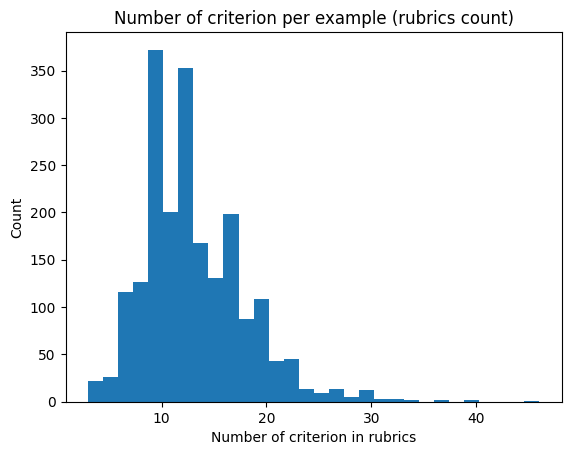

Max number of rubrics: 46
Min number of rubrics: 3
Mean number of rubrics: 13.17
Median number of rubrics: 12
Mode number of rubrics: 10, Frequency: 205
The number of samples containing 3 criteria in rubrics: 7
The number of samples containing 4 criteria in rubrics: 15
The number of samples containing 5 criteria in rubrics: 26
The number of samples containing 6 criteria in rubrics: 36
The number of samples containing 7 criteria in rubrics: 80
The number of samples containing 8 criteria in rubrics: 127
The number of samples containing 9 criteria in rubrics: 167
The number of samples containing 10 criteria in rubrics: 205
The number of samples containing 11 criteria in rubrics: 201
The number of samples containing 12 criteria in rubrics: 192
The number of samples containing 13 criteria in rubrics: 161
The number of samples containing 14 criteria in rubrics: 168
The number of samples containing 15 criteria in rubrics: 131
The number of samples containing 16 criteria in rubrics: 102
The nu

In [11]:
import matplotlib.pyplot as plt

# Count the number of rubrics for each example
rubrics_count = [len(example['rubrics']) for example in dataset]

# Visualize the distribution of rubrics numbers
plt.hist(rubrics_count, bins=30)
plt.title("Number of criterion per example (rubrics count)")
plt.xlabel("Number of criterion in rubrics")
plt.ylabel("Count")
plt.show()

# Print some statistics
print(f"Max number of rubrics: {max(rubrics_count)}")
print(f"Min number of rubrics: {min(rubrics_count)}")
print(f"Mean number of rubrics: {sum(rubrics_count)/len(rubrics_count):.2f}")
print(f"Median number of rubrics: {sorted(rubrics_count)[len(rubrics_count)//2]}")


from collections import Counter

# Count the number of occurrences
count_counter = Counter(rubrics_count)
mode_count = count_counter.most_common(1)[0][0]
mode_freq = count_counter.most_common(1)[0][1]

print(f"Mode number of rubrics: {mode_count}, Frequency: {mode_freq}")

rubrics_count = [len(example['rubrics']) for example in dataset]
count_counter = Counter(rubrics_count)

for num in sorted(count_counter):
    print(f"The number of samples containing {num} criteria in rubrics: {count_counter[num]}")

In [12]:
# Filter rubric number to be within a specific range (e.g., 8-10)
def rubric_count_in_range(example, min_count=8, max_count=10):
    return min_count <= len(example['rubrics']) <= max_count

dataset_rub_num = dataset.filter(rubric_count_in_range)
print(f"After rubric count filter (8-10): {len(dataset_rub_num)}")

Filter: 100%|██████████| 2063/2063 [00:00<00:00, 5949.74 examples/s]

After rubric count filter (8-10): 499


In [13]:
dataset = dataset_rub_num

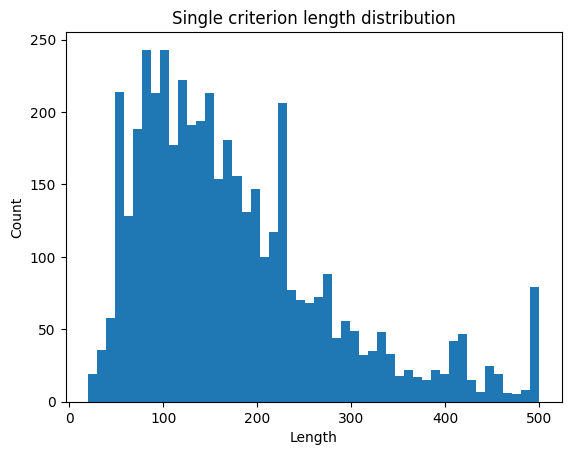

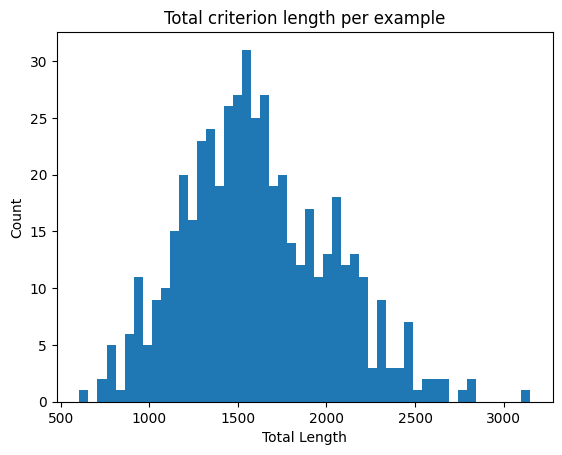

Single criterion max length: 500
Single criterion 75th percentile: 225
Total criterion max length: 3151
Total criterion 75th percentile: 1896


In [14]:
import matplotlib.pyplot as plt

# Calculate the length distribution of a single criterion
all_criterion_lens = []
total_criterion_lens = []

for example in dataset:
    criteria = [r['criterion'] for r in example['rubrics']]
    crit_lens = [len(c) for c in criteria]
    all_criterion_lens.extend(crit_lens)
    total_criterion_lens.append(sum(crit_lens))

# Single criterion length distribution
plt.hist(all_criterion_lens, bins=50)
plt.title("Single criterion length distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

# Total criterion length distribution
plt.hist(total_criterion_lens, bins=50)
plt.title("Total criterion length per example")
plt.xlabel("Total Length")
plt.ylabel("Count")
plt.show()

# Print some statistics
print(f"Single criterion max length: {max(all_criterion_lens)}")
print(f"Single criterion 75th percentile: {sorted(all_criterion_lens)[int(0.75*len(all_criterion_lens))]}")
print(f"Total criterion max length: {max(total_criterion_lens)}")
print(f"Total criterion 75th percentile: {sorted(total_criterion_lens)[int(0.75*len(total_criterion_lens))]}")

In [15]:
# Filter rubric length (total length < 5000, individual < 500)
def rubric_length_ok(example, total_thresh=5000):
    criteria = [r['criterion'] for r in example['rubrics']]
    total = sum(len(c) for c in criteria)
    return total < total_thresh 

dataset_length = dataset.filter(rubric_length_ok)
print(f"After rubric length filter: {len(dataset_length)}")

Filter: 100%|██████████| 499/499 [00:00<00:00, 6127.84 examples/s]

After rubric length filter: 499


In [21]:
dataset = dataset_length

In [17]:
import os

# Save as a JSONL file
os.makedirs("outputs/data", exist_ok=True)
dataset.to_json("outputs/data/rubrics_8_10.jsonl", orient="records", lines=True)

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  8.48ba/s]


5312248

In [22]:
# filter for examples that have a short conversation
def short_conversation(example):
    total_chars = sum(len(turn.get('content', '')) for turn in example.get('prompt', []))
    return total_chars < 300  # example threshold, adjust as needed

dataset_short_conversations = dataset.filter(short_conversation)
print(f"After short conversation filter: {len(dataset_short_conversations)}")


After short conversation filter: 254


In [23]:
import os

# Save as a JSONL file
os.makedirs("outputs/data", exist_ok=True)
dataset_short_conversations.to_json("outputs/data/rubrics_8_10_short.jsonl", orient="records", lines=True)

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 19.85ba/s]


2510415